In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import seaborn as sns
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import roc_auc_score, confusion_matrix

import warnings
warnings.filterwarnings("ignore")

In [2]:
DATA_PATH = r"..\Dataset\clean_data.csv"
CALIB_MODEL_PATH = r"..\models\calibrated_xgb_pipeline.pkl"

In [3]:
df = pd.read_csv(DATA_PATH)
df.head(5)

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,...,tolazamide,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,target
0,2278392,8222157,Caucasian,Female,5,Not_Available,Not_Mapped,Physician_Referral,1,41,...,No,No,No,No,No,No,No,No,No,0
1,64410,86047875,AfricanAmerican,Female,25,Emergency,Discharged_Home,Emergency_Room,2,11,...,No,No,No,No,No,No,No,No,Yes,0
2,500364,82442376,Caucasian,Male,35,Emergency,Discharged_Home,Emergency_Room,2,44,...,No,Up,No,No,No,No,No,Ch,Yes,0
3,16680,42519267,Caucasian,Male,45,Emergency,Discharged_Home,Emergency_Room,1,51,...,No,Steady,No,No,No,No,No,Ch,Yes,0
4,55842,84259809,Caucasian,Male,65,Elective,Discharged_Home,Clinic_Referral,4,70,...,No,Steady,No,No,No,No,No,Ch,Yes,0


In [4]:
def calculate_ece(y_true, y_prob, n_bins=10):
    bins = np.linspace(0., 1., n_bins + 1)
    binids = np.digitize(y_prob, bins) - 1
    ece = 0.0
    for i in range(n_bins):
        bin_mask = (binids == i)
        if bin_mask.sum() > 0:
            bin_acc = y_true[bin_mask].mean()
            bin_conf = y_prob[bin_mask].mean()
            bin_weight = bin_mask.sum() / len(y_prob)
            ece += bin_weight * np.abs(bin_acc - bin_conf)
    return ece

In [5]:
X = df.drop(columns=['target', 'encounter_id'])
y = df['target']
groups = df['patient_nbr']

gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
_, test_idx = next(gss.split(X, y, groups=groups))

X_test = X.iloc[test_idx].copy()
y_test = y.iloc[test_idx].copy()

In [6]:
# Load Model and Predict
calib_pipeline = joblib.load(CALIB_MODEL_PATH)
X_test['predicted_risk'] = calib_pipeline.predict_proba(X_test)[:, 1]
X_test['actual_readmission'] = y_test


    # Overall Metrics
overall_auc = roc_auc_score(X_test['actual_readmission'], X_test['predicted_risk'])
overall_ece = calculate_ece(X_test['actual_readmission'], X_test['predicted_risk'])
print(f"OVERALL BASELINE | AUC: {overall_auc:.4f} | ECE: {overall_ece:.4f}")

OVERALL BASELINE | AUC: 0.7374 | ECE: 0.0094


In [7]:
# 1. Create the Race × Gender intersection feature
X_test['race_gender'] = X_test['race'].astype(str) + " _ " + X_test['gender'].astype(str)
# Filter out unknown/invalid genders
X_test = X_test[~X_test['race_gender'].str.contains("Unknown/Invalid")]

# We will use the top 20% of risk scores as our fixed threshold for FNR and Selection Rate
threshold_val = X_test['predicted_risk'].quantile(0.80)

In [8]:
results = []
unique_groups = X_test['race_gender'].unique()

for group in unique_groups:
    sub = X_test[X_test['race_gender'] == group]

    # Need enough data in both classes to calculate metrics safely
    if len(sub) > 50 and len(sub['actual_readmission'].unique()) > 1:
        y_true = sub['actual_readmission']
        y_prob = sub['predicted_risk']
        y_pred_binary = (y_prob >= threshold_val).astype(int)

        sub_auc = roc_auc_score(y_true, y_prob)
        sub_ece = calculate_ece(y_true.values, y_prob.values)

        # Calculate False Negative Rate (FNR) = FN / (FN + TP)
        # Fraction of actual readmissions we MISSED
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred_binary).ravel()
        fnr = fn / (fn + tp) if (fn + tp) > 0 else 0

        # Calculate Selection Rate = (TP + FP) / Total
        # Fraction of this demographic flagged for intervention
        selection_rate = (tp + fp) / len(sub)

        results.append({
            'Subgroup': group,
            'N_Patients': len(sub),
            'AUC': sub_auc,
            'AUC_Gap': sub_auc - overall_auc,
            'ECE': sub_ece,
            'False_Negative_Rate': fnr,
            'Selection_Rate': selection_rate
        })

In [9]:
audit_df = pd.DataFrame(results).sort_values(by='AUC_Gap', ascending=True)

# Display the full table required by the blueprint
display(audit_df.round(4).style.applymap(
    lambda x: 'background-color: #ffcccc' if x < -0.05 else '', subset=['AUC_Gap']
))

,Subgroup,N_Patients,AUC,AUC_Gap,ECE,False_Negative_Rate,Selection_Rate
7,? _ Female,176,0.698600,-0.038800,0.014900,0.809500,0.085200
2,AfricanAmerican _ Male,952,0.711200,-0.026200,0.033500,0.560300,0.192200
9,Hispanic _ Male,115,0.722000,-0.015300,0.033800,0.631600,0.182600
5,Other _ Male,101,0.722900,-0.014500,0.093100,0.846200,0.128700
3,AfricanAmerican _ Female,1536,0.735400,-0.002000,0.015100,0.501900,0.225300
0,Caucasian _ Female,5015,0.737600,0.000200,0.011800,0.535700,0.213400
10,Hispanic _ Female,158,0.739500,0.002100,0.052800,0.500000,0.158200
1,Caucasian _ Male,4760,0.740700,0.003300,0.012700,0.552100,0.191800
8,Asian _ Male,53,0.746700,0.009300,0.079500,1.000000,0.113200
4,Other _ Female,91,0.750900,0.013500,0.058500,0.466700,0.197800


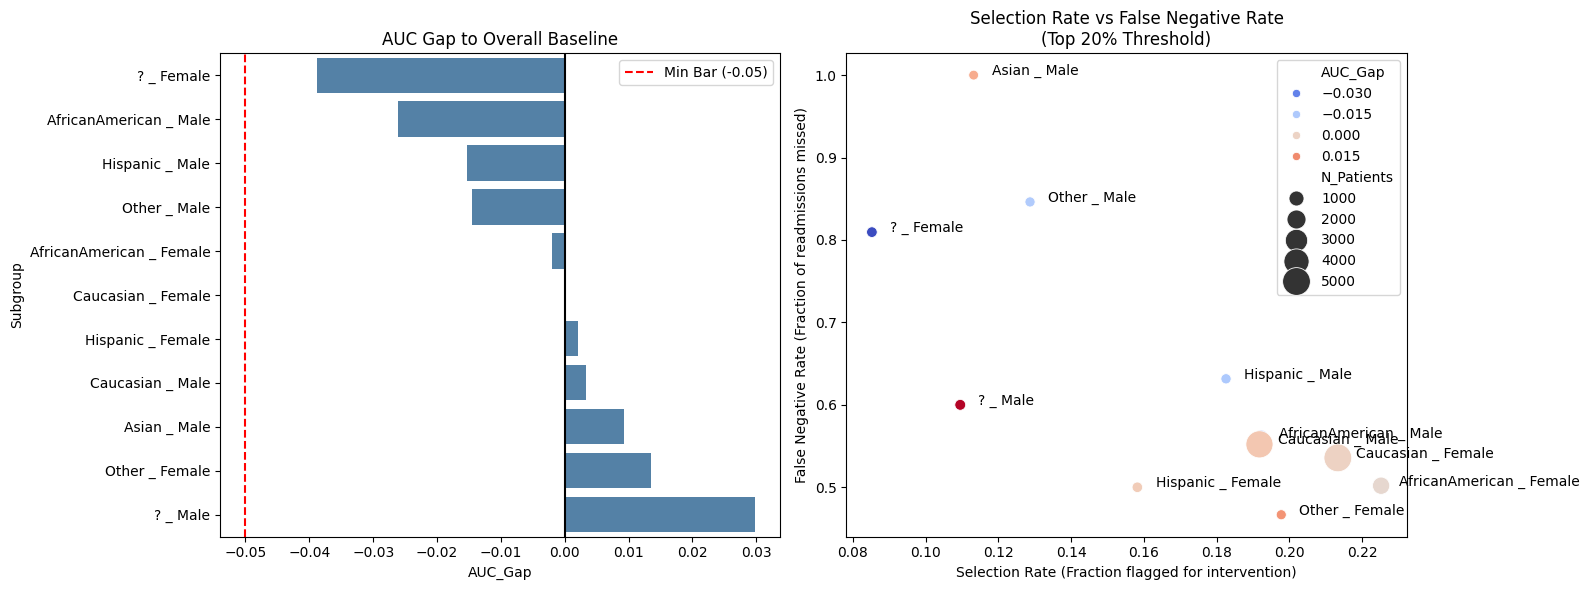

✅ AUDIT PASSED: No subgroup falls below the -0.05 AUC fairness threshold.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: AUC Gap
colors = ['red' if gap < -0.05 else 'steelblue' for gap in audit_df['AUC_Gap']]
sns.barplot(data=audit_df, x='AUC_Gap', y='Subgroup', palette=colors, ax=axes[0])
axes[0].axvline(x=0, color='black', linestyle='-')
axes[0].axvline(x=-0.05, color='red', linestyle='--', label='Min Bar (-0.05)')
axes[0].set_title('AUC Gap to Overall Baseline')
axes[0].legend()

# Plot 2: Selection Rate vs False Negative Rate
sns.scatterplot(data=audit_df, x='Selection_Rate', y='False_Negative_Rate',
                size='N_Patients', hue='AUC_Gap', palette='coolwarm', sizes=(50, 400), ax=axes[1])
axes[1].set_title('Selection Rate vs False Negative Rate\n(Top 20% Threshold)')
axes[1].set_xlabel('Selection Rate (Fraction flagged for intervention)')
axes[1].set_ylabel('False Negative Rate (Fraction of readmissions missed)')

# Add labels to points
for idx, row in audit_df.iterrows():
    axes[1].annotate(row['Subgroup'], (row['Selection_Rate']+0.005, row['False_Negative_Rate']))

plt.tight_layout()
plt.show()

# Final Blueprint Check
failed = audit_df[audit_df['AUC_Gap'] < -0.05]
if len(failed) == 0:
    print("✅ AUDIT PASSED: No subgroup falls below the -0.05 AUC fairness threshold.")
else:
    print(f"❌ AUDIT FAILED: {len(failed)} subgroups fell below the fairness threshold.")